# ₿ Bitcoin Quantitative Risk Analysis (2014–2026)
**Dataset:** Bitcoin historical prices — 4,280 días de datos (Sep 2014 – Jun 2026)  
**Objetivo:** Análisis cuantitativo de riesgo financiero.

---
## Tabla de contenidos
1. [Carga y preparación de datos](#1)
2. [Análisis de precio y retornos](#2)
3. [Risk Management — VaR, CVaR y Drawdown](#3)
4. [Simulación Monte Carlo](#4)
5. [Stress Testing](#5)
6. [Predicción de dirección de precio](#6)
7. [Conclusiones](#7)


## 1. Carga y Preparación de Datos <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('outputs', exist_ok=True)

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')


/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


In [2]:
df = pd.read_csv('data/bitcoin_dataset.csv')
print(f"Shape: {df.shape}")
df.head(3)

Shape: (4280, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700


In [3]:
df.tail(3)

,Date,Open,High,Low,Close,Adj Close,Volume
4277,2026-06-03,66694.007812,67402.929688,64009.675781,64014.367188,64014.367188,47411556213
4278,2026-06-04,64020.070312,64664.445312,61335.750000,63801.574219,63801.574219,63800151780
4279,2026-06-05,63807.691406,63901.515625,59108.917969,60922.667969,60922.667969,71465606706


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4280 entries, 0 to 4279
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4280 non-null   str    
 1   Open       4280 non-null   float64
 2   High       4280 non-null   float64
 3   Low        4280 non-null   float64
 4   Close      4280 non-null   float64
 5   Adj Close  4280 non-null   float64
 6   Volume     4280 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 234.2 KB


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ── Feature Engineering financiero ────────────────────────────────────────────
df['log_return']    = np.log(df['Close'] / df['Close'].shift(1))
df['pct_return']    = df['Close'].pct_change()
df['daily_range']   = (df['High'] - df['Low']) / df['Low'] * 100
df['Year']          = df['Date'].dt.year
df['Month']         = df['Date'].dt.month
df['DayOfWeek']     = df['Date'].dt.dayofweek

# Medias móviles
df['MA_21']  = df['Close'].rolling(21).mean()
df['MA_50']  = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()

# Volatilidad rolling
df['vol_30d'] = df['log_return'].rolling(30).std() * np.sqrt(365) * 100 # Bitcoin opera 365 días/año — usamos sqrt(365) para anualizar

df.dropna(subset=['log_return'], inplace=True)

print(f"   Datos preparados")
print(f"   Rango: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"   Días de trading: {len(df):,}")
print(f"   Precio mínimo: ${df['Close'].min():,.2f}")
print(f"   Precio máximo: ${df['Close'].max():,.2f}")
print(f"   Retorno medio diario: {df['log_return'].mean()*100:.3f}%")
print(f"   Volatilidad diaria:   {df['log_return'].std()*100:.3f}%")


   Datos preparados
   Rango: 2014-09-18 → 2026-06-05
   Días de trading: 4,279
   Precio mínimo: $178.10
   Precio máximo: $124,752.53
   Retorno medio diario: 0.114%
   Volatilidad diaria:   3.515%


## 2. Análisis de Precio y Retornos <a id='2'></a>

### 2.1 Evolución histórica del precio

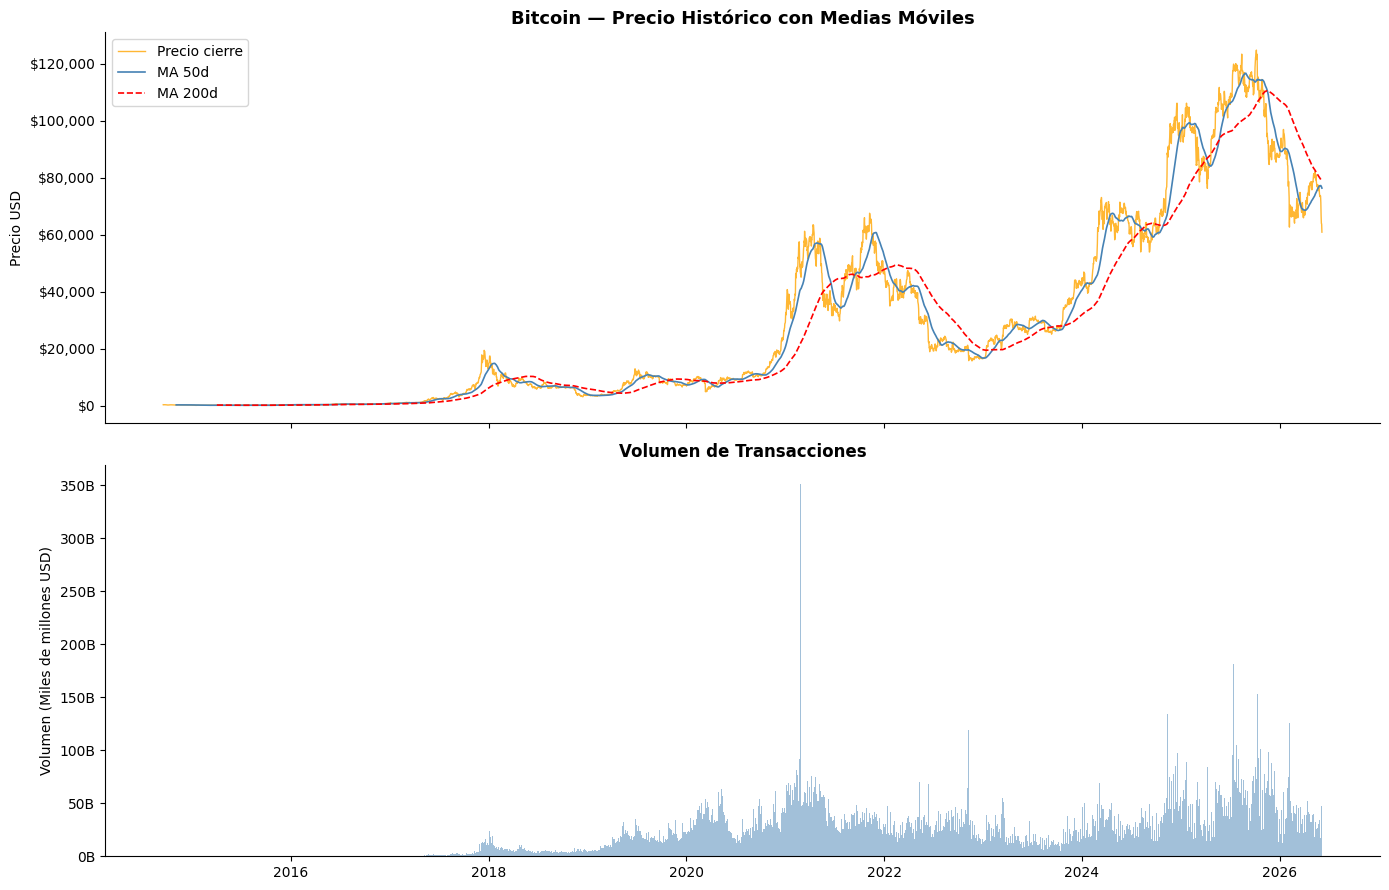

Se identifican claramente 3 ciclos alcistas: 2017, 2020-21 y 2024.


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Precio con medias móviles
axes[0].plot(df['Date'], df['Close'], color='orange', linewidth=1, alpha=0.8, label='Precio cierre')
axes[0].plot(df['Date'], df['MA_50'],  color='steelblue', linewidth=1.2, label='MA 50d')
axes[0].plot(df['Date'], df['MA_200'], color='red', linewidth=1.2, linestyle='--', label='MA 200d')
axes[0].set_ylabel('Precio USD')
axes[0].set_title('Bitcoin — Precio Histórico con Medias Móviles', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# Volumen
axes[1].bar(df['Date'], df['Volume'] / 1e9, color='steelblue', alpha=0.5, width=1)
axes[1].set_ylabel('Volumen (Miles de millones USD)')
axes[1].set_title('Volumen de Transacciones', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}B'))

plt.tight_layout()
plt.savefig('outputs/btc_01_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()  # ← agregar esto
print("Se identifican claramente 3 ciclos alcistas: 2017, 2020-21 y 2024.")


### 2.2 Retornos anuales y volatilidad

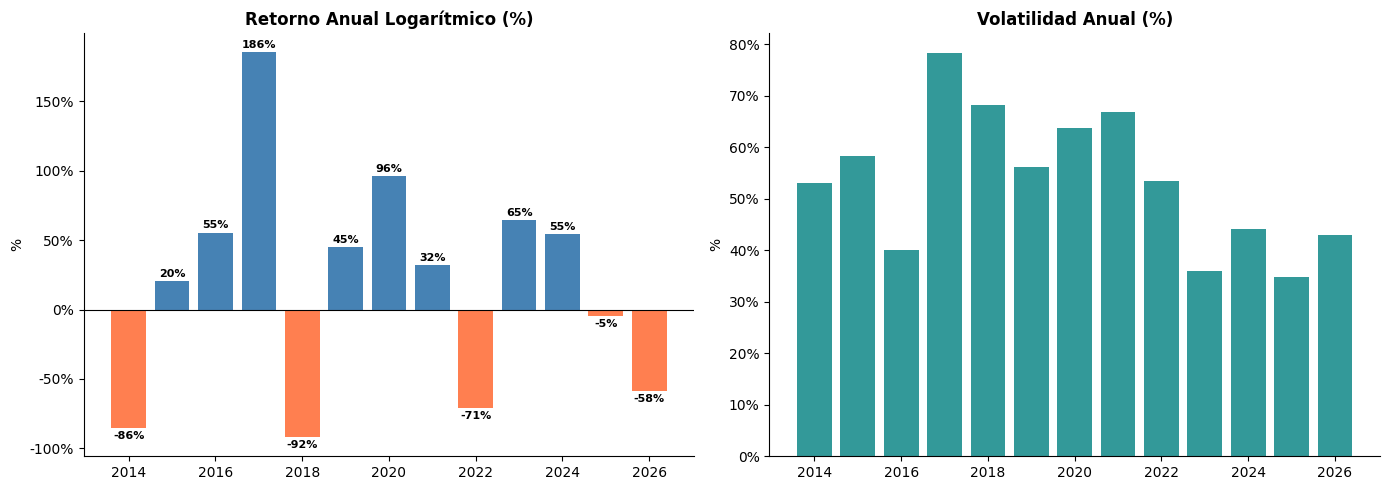

Tabla de métricas anuales:
 Year  annual_return  annual_vol  sharpe
 2014         -85.56       53.00   -1.61
 2015          20.45       58.34    0.35
 2016          55.48       40.08    1.38
 2017         185.52       78.26    2.37
 2018         -91.85       68.09   -1.35
 2019          45.11       56.08    0.80
 2020          95.99       63.61    1.51
 2021          32.31       66.74    0.48
 2022         -71.05       53.36   -1.33
 2023          64.74       35.96    1.80
 2024          54.62       44.15    1.24
 2025          -4.52       34.82   -0.13
 2026         -58.50       42.95   -1.36


In [7]:
yearly = df.groupby('Year')['log_return'].agg(['mean', 'std']).reset_index()
yearly['annual_return'] = yearly['mean'] * 252 * 100
yearly['annual_vol']    = yearly['std'] * np.sqrt(252) * 100
yearly['sharpe']        = (yearly['mean'] * 252) / (yearly['std'] * np.sqrt(252))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Retorno anual
colors = ['coral' if r < 0 else 'steelblue' for r in yearly['annual_return']]
bars = axes[0].bar(yearly['Year'], yearly['annual_return'], color=colors)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Retorno Anual Logarítmico (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('%')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for bar, val in zip(bars, yearly['annual_return']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (3 if val >= 0 else -8),
                 f'{val:.0f}%', ha='center', fontsize=8, fontweight='bold')

# Volatilidad anual
axes[1].bar(yearly['Year'], yearly['annual_vol'], color='teal', alpha=0.8)
axes[1].set_title('Volatilidad Anual (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('%')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('outputs/btc_02_annual_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print("Tabla de métricas anuales:")
print(yearly[['Year', 'annual_return', 'annual_vol', 'sharpe']].round(2).to_string(index=False))


### 2.3 Distribución de retornos — Fat Tails

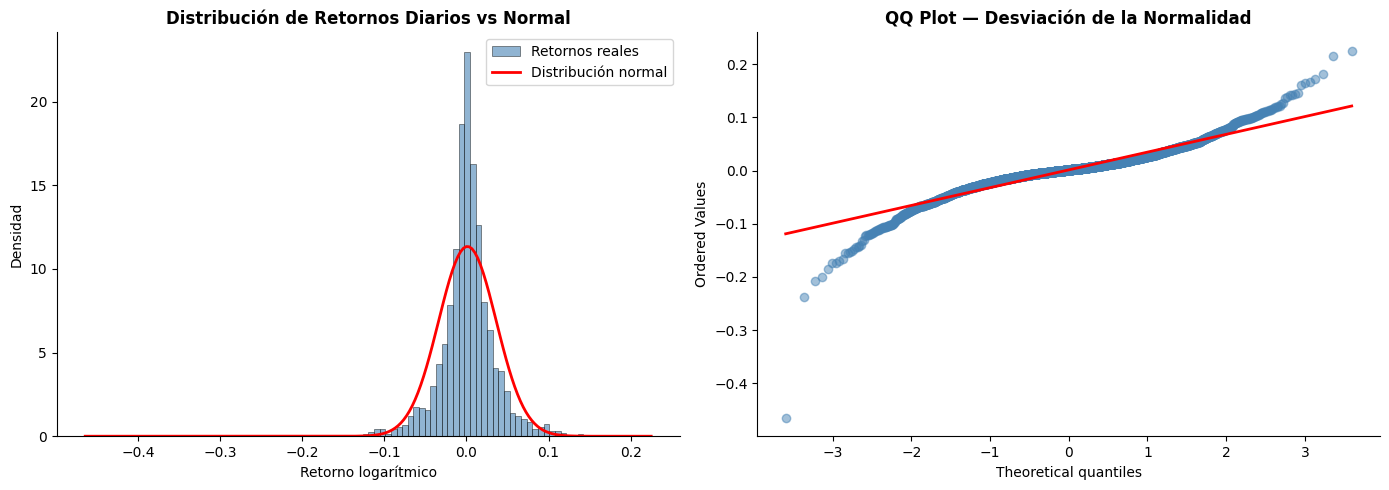

Kurtosis: 11.800 (Normal=0) — colas más pesadas que una distribución normal
Skewness: -0.706 (Normal=0)
Las fat tails significan que eventos extremos ocurren más frecuentemente de lo que predice la teoría clásica.


In [8]:
returns = df['log_return'].dropna()
mu, sigma = returns.mean(), returns.std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma vs distribución normal
x = np.linspace(returns.min(), returns.max(), 200)
normal_pdf = stats.norm.pdf(x, mu, sigma)

axes[0].hist(returns, bins=100, density=True, color='steelblue', alpha=0.6, label='Retornos reales', edgecolor='black', linewidth=0.5)
axes[0].plot(x, normal_pdf, color='red', linewidth=2, label='Distribución normal')
axes[0].set_title('Distribución de Retornos Diarios vs Normal', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Retorno logarítmico')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# QQ Plot
stats.probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot — Desviación de la Normalidad', fontsize=12, fontweight='bold')
axes[1].get_lines()[0].set(color='steelblue', alpha=0.5)
axes[1].get_lines()[1].set(color='red', linewidth=2)

plt.tight_layout()
plt.savefig('outputs/btc_03_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

kurt = stats.kurtosis(returns)
skew = stats.skew(returns)
print(f"Kurtosis: {kurt:.3f} (Normal=0) — colas más pesadas que una distribución normal")
print(f"Skewness: {skew:.3f} (Normal=0)")
print(f"Las fat tails significan que eventos extremos ocurren más frecuentemente de lo que predice la teoría clásica.")


### 2.4 Volatilidad rolling a 30 días

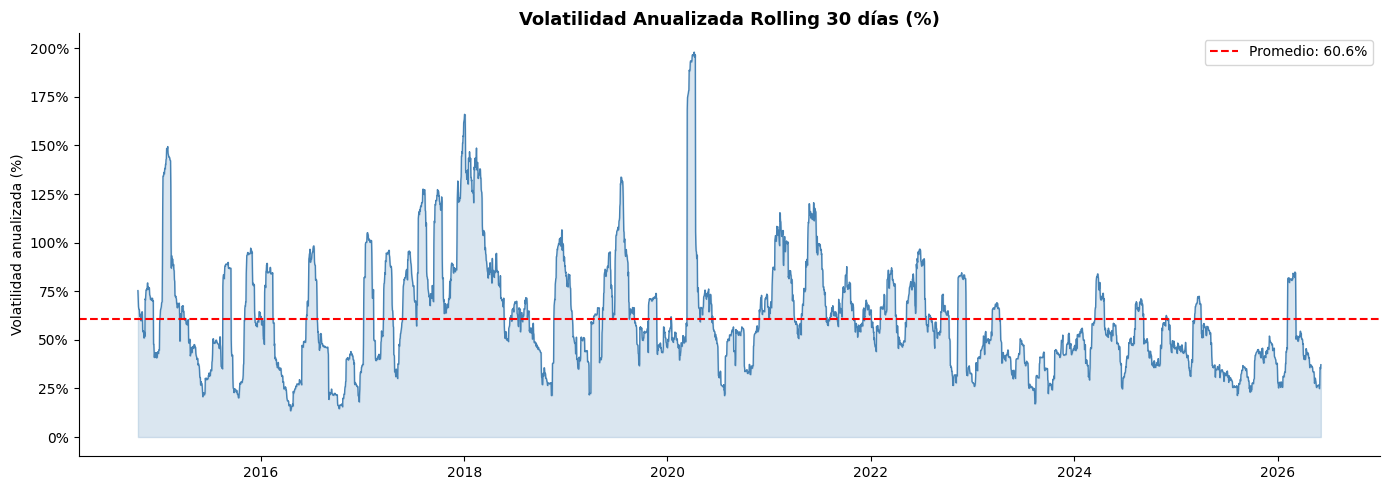

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'], df['vol_30d'], color='steelblue', linewidth=1)
ax.fill_between(df['Date'], df['vol_30d'], alpha=0.2, color='steelblue')
ax.axhline(df['vol_30d'].mean(), color='red', linestyle='--', 
           label=f'Promedio: {df["vol_30d"].mean():.1f}%')
ax.set_title('Volatilidad Anualizada Rolling 30 días (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Volatilidad anualizada (%)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend()

plt.tight_layout()
plt.savefig('outputs/btc_04_rolling_vol.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Risk Management — VaR, CVaR y Drawdown <a id='3'></a>

### 3.1 Value at Risk (VaR) y Expected Shortfall (CVaR)

**VaR al 95%:** La pérdida máxima esperada en un día normal (95% de confianza).  
**CVaR al 95%:** El promedio de pérdidas en el peor 5% de los días — más conservador que el VaR.


In [10]:
returns = df['log_return'].dropna()

# VaR histórico
var_95 = np.percentile(returns, 5)
var_99 = np.percentile(returns, 1)

# CVaR (Expected Shortfall)
cvar_95 = returns[returns <= var_95].mean()
cvar_99 = returns[returns <= var_99].mean()

print("=" * 50)
print("   VALUE AT RISK — MÉTODO HISTÓRICO")
print("=" * 50)
print(f"  VaR  95% (1 día): {var_95*100:.2f}%  →  ${10000 * abs(var_95):,.0f} por cada $10,000 invertidos")
print(f"  VaR  99% (1 día): {var_99*100:.2f}%  →  ${10000 * abs(var_99):,.0f} por cada $10,000 invertidos")
print(f"  CVaR 95% (1 día): {cvar_95*100:.2f}%  →  ${10000 * abs(cvar_95):,.0f} por cada $10,000 invertidos")
print(f"  CVaR 99% (1 día): {cvar_99*100:.2f}%  →  ${10000 * abs(cvar_99):,.0f} por cada $10,000 invertidos")
print("=" * 50)

# VaR Paramétrico (asume normalidad)
var_95_param = stats.norm.ppf(0.05, mu, sigma)
var_99_param = stats.norm.ppf(0.01, mu, sigma)
print(f" VaR 95% Paramétrico: {var_95_param*100:.2f}%")
print(f" VaR 99% Paramétrico: {var_99_param*100:.2f}%")
print(f" El VaR histórico es más pesimista que el paramétrico — confirma las fat tails.")


   VALUE AT RISK — MÉTODO HISTÓRICO
  VaR  95% (1 día): -5.43%  →  $543 por cada $10,000 invertidos
  VaR  99% (1 día): -10.56%  →  $1,056 por cada $10,000 invertidos
  CVaR 95% (1 día): -8.60%  →  $860 por cada $10,000 invertidos
  CVaR 99% (1 día): -14.38%  →  $1,438 por cada $10,000 invertidos
 VaR 95% Paramétrico: -5.67%
 VaR 99% Paramétrico: -8.06%
 El VaR histórico es más pesimista que el paramétrico — confirma las fat tails.


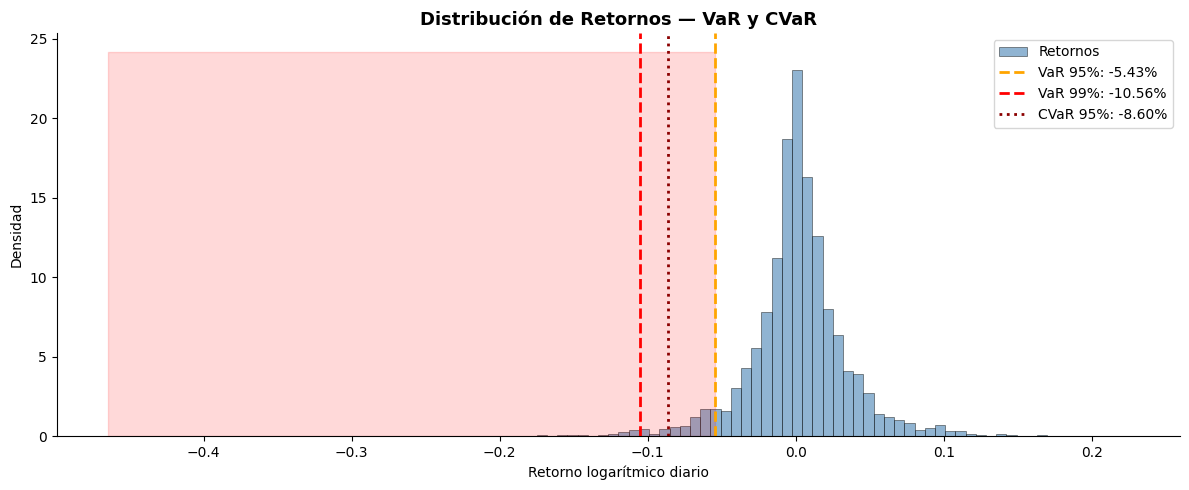

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(returns, bins=100, density=True, color='steelblue', alpha=0.6, label='Retornos', edgecolor='black', linewidth=0.5)
ax.axvline(var_95,  color='orange', linewidth=2, linestyle='--', label=f'VaR 95%: {var_95*100:.2f}%')
ax.axvline(var_99,  color='red',    linewidth=2, linestyle='--', label=f'VaR 99%: {var_99*100:.2f}%')
ax.axvline(cvar_95, color='darkred',linewidth=2, linestyle=':',  label=f'CVaR 95%: {cvar_95*100:.2f}%')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 10],
                  returns.min(), var_95, alpha=0.15, color='red')

ax.set_title('Distribución de Retornos — VaR y CVaR', fontsize=13, fontweight='bold')
ax.set_xlabel('Retorno logarítmico diario')
ax.set_ylabel('Densidad')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/btc_05_var.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.2 Maximum Drawdown

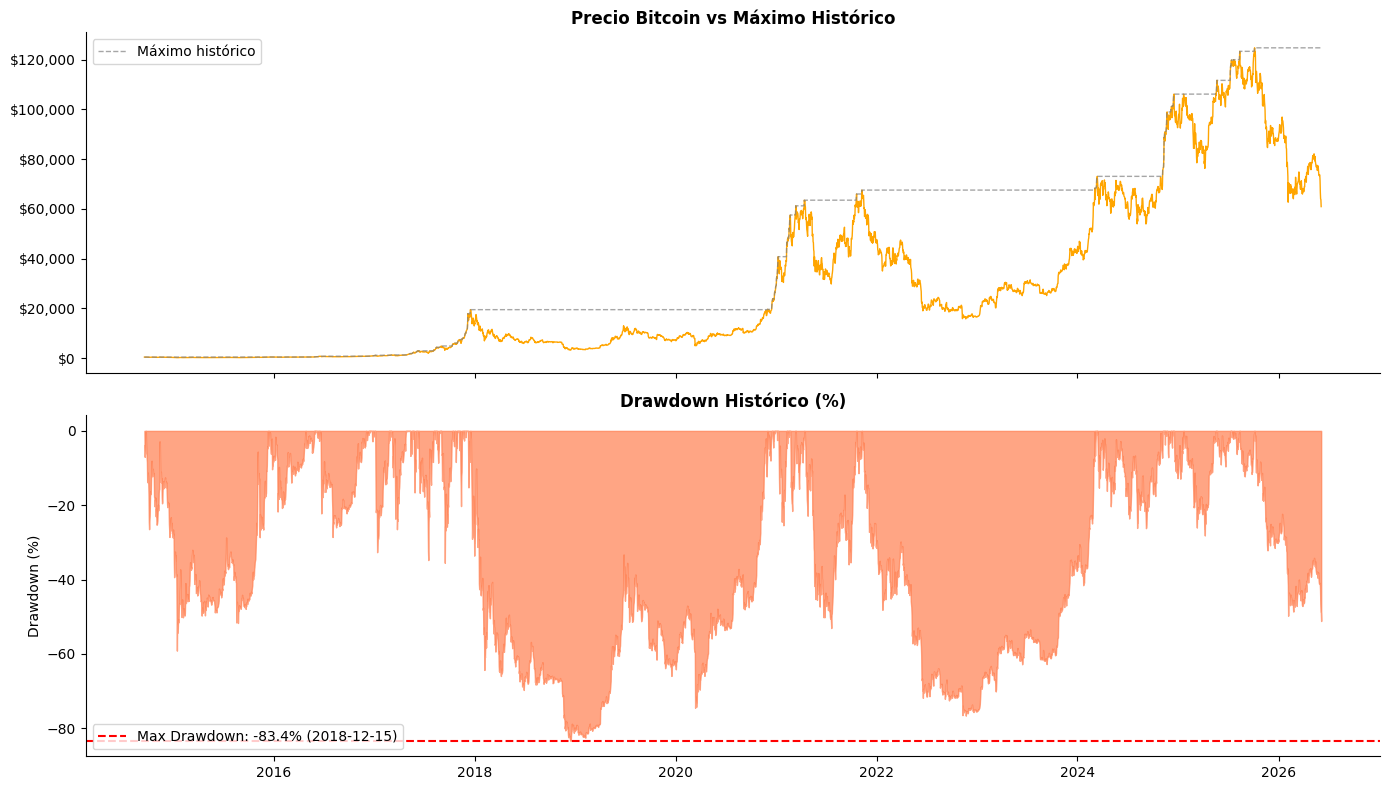

 Maximum Drawdown histórico: -83.4% — la mayor caída desde un pico.


In [12]:
# Calcular drawdown histórico
df['cummax'] = df['Close'].cummax()
df['drawdown'] = (df['Close'] - df['cummax']) / df['cummax'] * 100

max_dd = df['drawdown'].min()
max_dd_date = df.loc[df['drawdown'].idxmin(), 'Date']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df['Date'], df['Close'], color='orange', linewidth=1)
axes[0].plot(df['Date'], df['cummax'], color='gray', linewidth=1, linestyle='--', alpha=0.7, label='Máximo histórico')
axes[0].set_title('Precio Bitcoin vs Máximo Histórico', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

axes[1].fill_between(df['Date'], df['drawdown'], 0, color='coral', alpha=0.7)
axes[1].axhline(max_dd, color='red', linestyle='--', linewidth=1.5,
                label=f'Max Drawdown: {max_dd:.1f}% ({max_dd_date.date()})')
axes[1].set_title('Drawdown Histórico (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/btc_06_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Maximum Drawdown histórico: {max_dd:.1f}% — la mayor caída desde un pico.")


### 3.3 Sharpe Ratio por año

 Year    Sharpe   rf
 2014 -1.668147 2.86
 2015  0.318277 1.88
 2016  1.332006 2.09
 2017  2.339390 2.43
 2018 -1.386746 2.58
 2019  0.756005 2.71
 2020  1.481317 1.76
 2021  0.467873 1.08
 2022 -1.364464 1.76
 2023  1.702134 3.53
 2024  1.145104 4.06
 2025 -0.262798 4.63
 2026 -1.465567 4.45


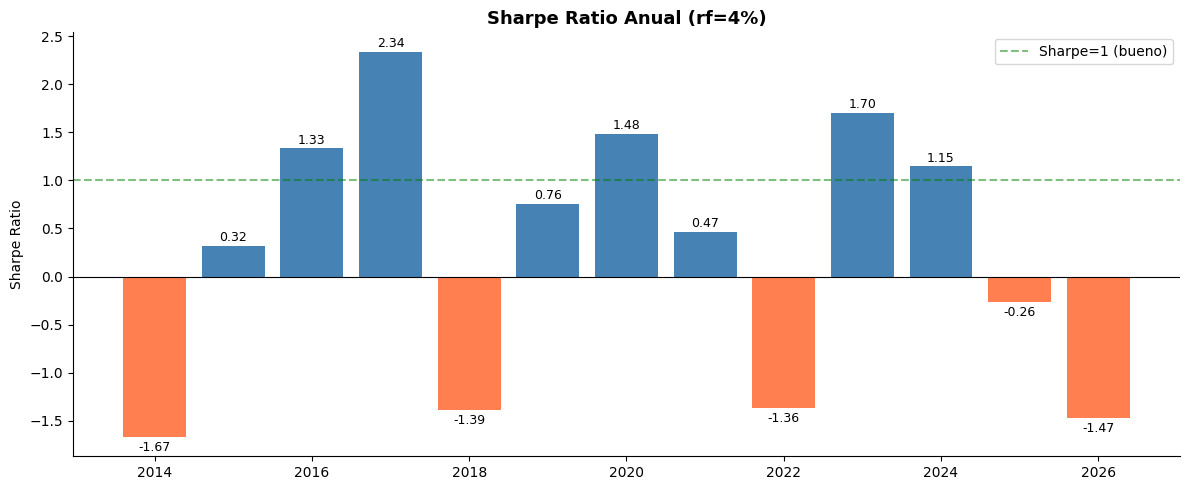

 Sharpe > 1 indica retorno ajustado por riesgo excelente. 2017, 2020, y 2022 fueron años excepcionales.


In [13]:
# Tasa libre de riesgo dinámica por año (10Y Treasury)
rf_by_year = {
    2014: 0.0286, 2015: 0.0188, 2016: 0.0209,
    2017: 0.0243, 2018: 0.0258, 2019: 0.0271,
    2020: 0.0176, 2021: 0.0108, 2022: 0.0176,
    2023: 0.0353, 2024: 0.0406, 2025: 0.0463,
    2026: 0.0445
}

sharpe_yearly = []
for year, group in df.groupby('Year'):
    rf_annual = rf_by_year.get(year, 0.04)
    rf_daily  = rf_annual / 252
    excess_returns = group['log_return'] - rf_daily
    sharpe = excess_returns.mean() / excess_returns.std() * np.sqrt(252)
    sharpe_yearly.append({'Year': year, 'Sharpe': sharpe, 'rf': rf_annual*100})

sharpe_yearly = pd.DataFrame(sharpe_yearly)
print(sharpe_yearly.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['coral' if s < 0 else 'steelblue' for s in sharpe_yearly['Sharpe']]
bars = ax.bar(sharpe_yearly['Year'], sharpe_yearly['Sharpe'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(1, color='green', linestyle='--', alpha=0.5, label='Sharpe=1 (bueno)')
ax.set_title('Sharpe Ratio Anual (rf=4%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.legend()

for bar, val in zip(bars, sharpe_yearly['Sharpe']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.05 if val >= 0 else -0.15),
            f'{val:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/btc_07_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Sharpe > 1 indica retorno ajustado por riesgo excelente. 2017, 2020, y 2022 fueron años excepcionales.")


## 4. Simulación Monte Carlo <a id='4'></a>

Comparamos dos modelos estocásticos para simular trayectorias de precio a 30 días:

| Modelo | Volatilidad | Saltos | Fat Tails |
|--------|-------------|--------|-----------|
| **GBM** | Constante | No | No |
| **Merton Jump Diffusion** | Constante | Sí (Poisson) | Sí |

**¿Por qué no GBM puro?** Bitcoin experimenta saltos abruptos por eventos discretos (regulaciones, hacks, anuncios de ETFs). El GBM asume movimientos continuos y suaves — irreales para un activo con fat tails confirmadas en la Sección 2.


### 4.1 Calibración empírica de parámetros

En lugar de asumir parámetros arbitrarios, calibramos Merton directamente con los datos históricos de Bitcoin.

**Definición de salto:** día cuyo retorno logarítmico supera 3 desviaciones estándar de la media — umbral estándar en literatura de jump-diffusion para separar movimientos normales de shocks extremos.


   CALIBRACIÓN EMPÍRICA — MERTON JUMP DIFFUSION
  Días analizados:         4,279
  Días con salto (>3σ):    76 (1.78% del tiempo)
  Frecuencia (λ):          0.0178 (~6.5 saltos/año)
  Tamaño medio salto (μⱼ): -0.0231 (-2.31%)
  Volatilidad salto (σⱼ):  0.1468 (14.68%)

  Parámetros difusión:
  Retorno medio diario:    0.001143
  Volatilidad diaria:      0.035148
  Precio actual (S₀):      $60,922.67


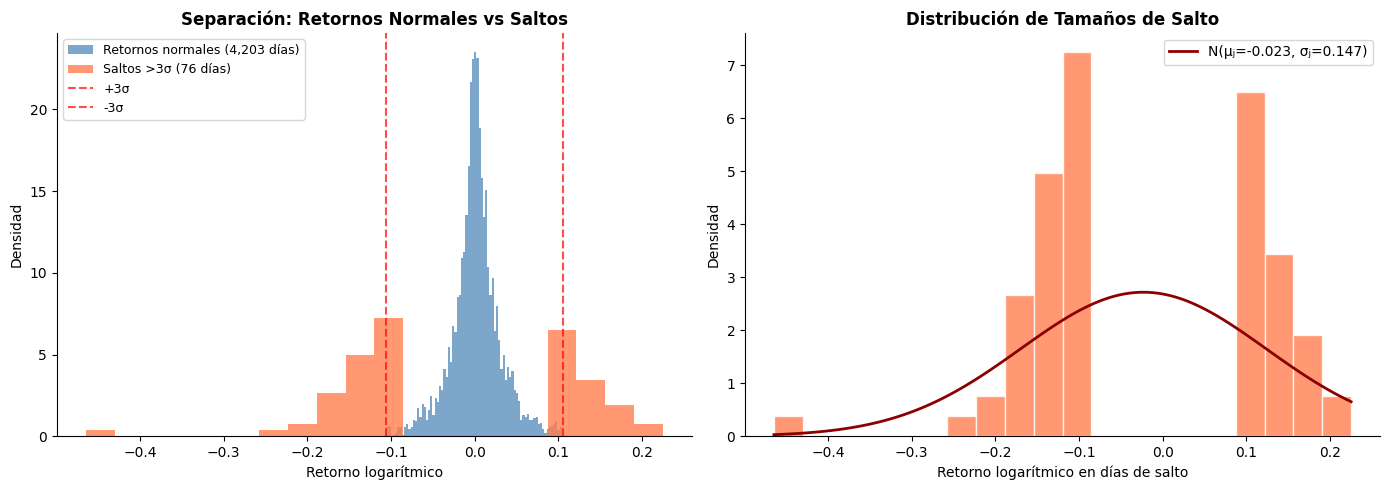

 Los saltos tienen sesgo negativo — los crashes son más frecuentes que los rallies extremos.


In [14]:
# ── Calibración empírica de parámetros de salto ───────────────────────────────
THRESHOLD = 3  # desviaciones estándar

jump_mask  = np.abs(returns) > THRESHOLD * returns.std()
normal_mask = ~jump_mask

# Parámetros base
mu_daily  = returns.mean()
sig_daily = returns.std()
S0        = df['Close'].iloc[-1]

# Parámetros de salto calibrados
lam_cal   = jump_mask.sum() / len(returns)   # frecuencia diaria
mu_j_cal  = returns[jump_mask].mean()         # tamaño medio del salto
sig_j_cal = returns[jump_mask].std()          # dispersión del salto

print("=" * 52)
print("   CALIBRACIÓN EMPÍRICA — MERTON JUMP DIFFUSION")
print("=" * 52)
print(f"  Días analizados:         {len(returns):,}")
print(f"  Días con salto (>3σ):    {jump_mask.sum():,} ({lam_cal*100:.2f}% del tiempo)")
print(f"  Frecuencia (λ):          {lam_cal:.4f} (~{lam_cal*365:.1f} saltos/año)")
print(f"  Tamaño medio salto (μⱼ): {mu_j_cal:.4f} ({mu_j_cal*100:.2f}%)")
print(f"  Volatilidad salto (σⱼ):  {sig_j_cal:.4f} ({sig_j_cal*100:.2f}%)")
print("=" * 52)
print(f"\n  Parámetros difusión:")
print(f"  Retorno medio diario:    {mu_daily:.6f}")
print(f"  Volatilidad diaria:      {sig_daily:.6f}")
print(f"  Precio actual (S₀):      ${S0:,.2f}")

# Visualizar separación normal vs salto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(returns[normal_mask], bins=80, density=True,
             color='steelblue', alpha=0.7, label=f'Retornos normales ({(~jump_mask).sum():,} días)')
axes[0].hist(returns[jump_mask],  bins=20, density=True,
             color='coral', alpha=0.8, label=f'Saltos >3σ ({jump_mask.sum()} días)')
axes[0].axvline(THRESHOLD * returns.std(),  color='red', linestyle='--', alpha=0.7, label='+3σ')
axes[0].axvline(-THRESHOLD * returns.std(), color='red', linestyle='--', alpha=0.7, label='-3σ')
axes[0].set_title('Separación: Retornos Normales vs Saltos', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Retorno logarítmico')
axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=9)

# Distribución de los saltos
axes[1].hist(returns[jump_mask], bins=20, density=True,
             color='coral', alpha=0.8, edgecolor='white')
x_j = np.linspace(returns[jump_mask].min(), returns[jump_mask].max(), 100)
axes[1].plot(x_j, stats.norm.pdf(x_j, mu_j_cal, sig_j_cal),
             color='darkred', linewidth=2, label=f'N(μⱼ={mu_j_cal:.3f}, σⱼ={sig_j_cal:.3f})')
axes[1].set_title('Distribución de Tamaños de Salto', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Retorno logarítmico en días de salto')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/btc_08a_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Los saltos tienen sesgo negativo — los crashes son más frecuentes que los rallies extremos.")


### 4.2 Simulación GBM y Merton

Generamos 1,000 trayectorias de 30 días con cada modelo usando los parámetros calibrados.


In [15]:
from scipy import stats as scipy_stats

np.random.seed(42)

T     = 30
N_sim = 1000
dt    = 1

# ══════════════════════════════════════════════════════════════════════════════
# GBM — Movimiento Browniano Geométrico
# Corrección de Itô: (μ - 0.5σ²) garantiza E[S_t] = S_0·e^(μt)
# ══════════════════════════════════════════════════════════════════════════════
gbm_shocks = np.random.normal(
    (mu_daily - 0.5 * sig_daily**2) * dt,
    sig_daily * np.sqrt(dt),
    size=(T, N_sim)
)
price_paths_gbm = S0 * np.exp(np.cumsum(gbm_shocks, axis=0))
price_paths_gbm = np.vstack([np.full(N_sim, S0), price_paths_gbm])
final_gbm       = price_paths_gbm[-1]

# ══════════════════════════════════════════════════════════════════════════════
# MERTON JUMP DIFFUSION — implementación del artículo (Simplified Zone)
# Parámetros calibrados empíricamente con datos históricos de Bitcoin
# ══════════════════════════════════════════════════════════════════════════════

# Corrección de media por presencia de saltos: k = E[J-1] = e^(μⱼ+0.5σⱼ²) - 1
k_jump = np.exp(mu_j_cal + 0.5 * sig_j_cal**2) - 1
drift_m = mu_daily - lam_cal * k_jump

# Componente de difusión ajustado
gbm_shocks_m = np.random.normal(
    (drift_m - 0.5 * sig_daily**2) * dt,
    sig_daily * np.sqrt(dt),
    size=(T, N_sim)
)

# Componente de salto — implementación exacta del artículo
# Para cada paso y cada simulación, sumamos saltos individuales
total_jump = np.zeros((T, N_sim))
for t in range(T):
    n_jumps = np.random.poisson(lam_cal * dt, N_sim)
    for sim in range(N_sim):
        if n_jumps[sim] > 0:
            jump_sizes = np.random.normal(mu_j_cal, sig_j_cal, n_jumps[sim])
            total_jump[t, sim] = np.sum(jump_sizes)

jump_factor = np.exp(total_jump)

# Precio final = GBM_difusión × factor_salto
price_paths_merton = np.zeros((T + 1, N_sim))
price_paths_merton[0] = S0
for t in range(T):
    price_paths_merton[t+1] = (price_paths_merton[t]
                                * np.exp((drift_m - 0.5 * sig_daily**2) * dt
                                         + sig_daily * np.sqrt(dt)
                                         * np.random.normal(0, 1, N_sim))
                                * jump_factor[t])

final_merton = price_paths_merton[-1]

print(f" GBM:    {N_sim:,} trayectorias × {T} días")
print(f" Merton: {N_sim:,} trayectorias × {T} días")
print(f"   λ={lam_cal:.4f} | μⱼ={mu_j_cal:.4f} | σⱼ={sig_j_cal:.4f} | k={k_jump:.4f}")


 GBM:    1,000 trayectorias × 30 días
 Merton: 1,000 trayectorias × 30 días
   λ=0.0178 | μⱼ=-0.0231 | σⱼ=0.1468 | k=-0.0123


### 4.3 Distribuciones de retornos por modelo

Cada modelo genera una distribución de retornos característica. Comparamos ambas contra los retornos históricos reales de Bitcoin y contra la distribución normal teórica.


   ESTADÍSTICAS DE RETORNOS LOGARÍTMICOS A 30 DÍAS
  Histórico real         | Skew: +0.205 | Kurtosis: 1.557 | Std: 0.2052 | Min: -0.924 | Max: 1.074
  GBM simulado           | Skew: -0.108 | Kurtosis: 0.012 | Std: 0.1950 | Min: -0.766 | Max: 0.533
  Merton simulado        | Skew: -0.058 | Kurtosis: 0.554 | Std: 0.2194 | Min: -0.844 | Max: 0.953
  Normal teórica         | Skew:  0.000 | Kurtosis:  0.000


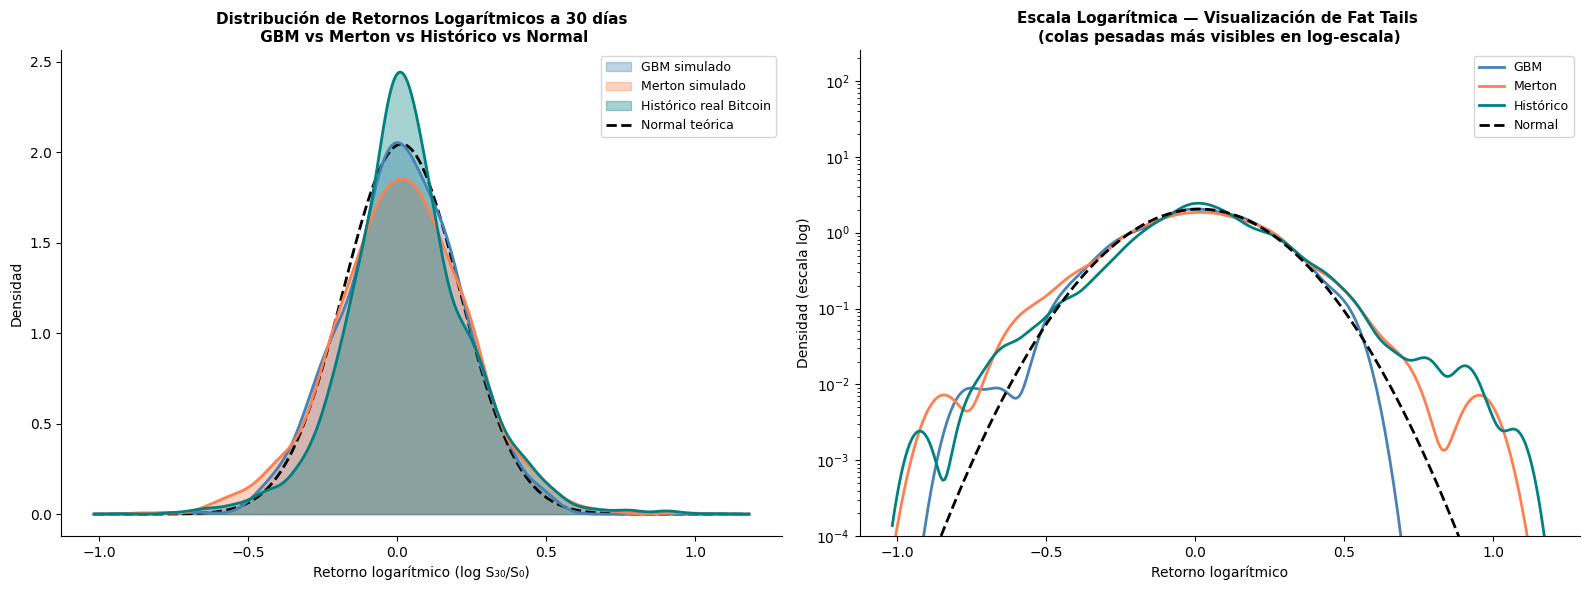

 GBM genera distribución normal — subestima eventos extremos.
 Merton genera colas más pesadas — más cercano al histórico real.
 En escala log las diferencias en las colas son dramáticas.


In [16]:
# Retornos logarítmicos simulados al día 30
log_returns_gbm    = np.log(final_gbm    / S0)
log_returns_merton = np.log(final_merton / S0)

# Estadísticas de cada distribución
def estadisticas(r, nombre):
    kurt = scipy_stats.kurtosis(r)
    skew = scipy_stats.skew(r)
    print(f"  {nombre:<22} | Skew: {skew:+.3f} | Kurtosis: {kurt:.3f} | "
          f"Std: {r.std():.4f} | Min: {r.min():.3f} | Max: {r.max():.3f}")

# Retornos históricos reales a 30 días
log_ret_hist_30 = np.log(df['Close'] / df['Close'].shift(30)).dropna()

print("=" * 72)
print("   ESTADÍSTICAS DE RETORNOS LOGARÍTMICOS A 30 DÍAS")
print("=" * 72)
estadisticas(log_ret_hist_30.values, 'Histórico real')
estadisticas(log_returns_gbm,        'GBM simulado')
estadisticas(log_returns_merton,     'Merton simulado')
print("=" * 72)
print("  Normal teórica         | Skew:  0.000 | Kurtosis:  0.000")

# ── Visualización comparativa de distribuciones ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rango común
x_min = min(log_returns_gbm.min(), log_returns_merton.min(), log_ret_hist_30.min()) * 1.1
x_max = max(log_returns_gbm.max(), log_returns_merton.max(), log_ret_hist_30.max()) * 1.1
x_range = np.linspace(x_min, x_max, 300)

# KDE de cada distribución
kde_gbm    = scipy_stats.gaussian_kde(log_returns_gbm)
kde_merton = scipy_stats.gaussian_kde(log_returns_merton)
kde_hist   = scipy_stats.gaussian_kde(log_ret_hist_30)
mu_n, sig_n = log_returns_gbm.mean(), log_returns_gbm.std()

# ── Gráfica 1: Distribuciones superpuestas ────────────────────────────────────
axes[0].fill_between(x_range, kde_gbm(x_range),
                     alpha=0.35, color='steelblue', label='GBM simulado')
axes[0].fill_between(x_range, kde_merton(x_range),
                     alpha=0.35, color='coral', label='Merton simulado')
axes[0].fill_between(x_range, kde_hist(x_range),
                     alpha=0.35, color='teal', label='Histórico real Bitcoin')
axes[0].plot(x_range, scipy_stats.norm.pdf(x_range, mu_n, sig_n),
             color='black', linewidth=2, linestyle='--', label='Normal teórica')

axes[0].plot(x_range, kde_gbm(x_range),    color='steelblue', linewidth=2)
axes[0].plot(x_range, kde_merton(x_range), color='coral',     linewidth=2)
axes[0].plot(x_range, kde_hist(x_range),   color='teal',      linewidth=2)

axes[0].set_title('Distribución de Retornos Logarítmicos a 30 días\n GBM vs Merton vs Histórico vs Normal',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Retorno logarítmico (log S₃₀/S₀)')
axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=9)

# ── Gráfica 2: Zoom en colas (fat tails) ─────────────────────────────────────
tail_range = np.linspace(x_min, np.percentile(log_returns_merton, 5), 100)

axes[1].semilogy(x_range, kde_gbm(x_range),    color='steelblue', linewidth=2, label='GBM')
axes[1].semilogy(x_range, kde_merton(x_range), color='coral',     linewidth=2, label='Merton')
axes[1].semilogy(x_range, kde_hist(x_range),   color='teal',      linewidth=2, label='Histórico')
axes[1].semilogy(x_range, scipy_stats.norm.pdf(x_range, mu_n, sig_n),
                 color='black', linewidth=2, linestyle='--', label='Normal')

axes[1].set_title('Escala Logarítmica — Visualización de Fat Tails \n(colas pesadas más visibles en log-escala)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Retorno logarítmico')
axes[1].set_ylabel('Densidad (escala log)')
axes[1].legend(fontsize=9)
axes[1].set_ylim(bottom=1e-4)

plt.tight_layout()
plt.savefig('outputs/btc_08b_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(" GBM genera distribución normal — subestima eventos extremos.")
print(" Merton genera colas más pesadas — más cercano al histórico real.")
print(" En escala log las diferencias en las colas son dramáticas.")


### 4.4 Comparativa visual — Trayectorias y Volume Profile de precios


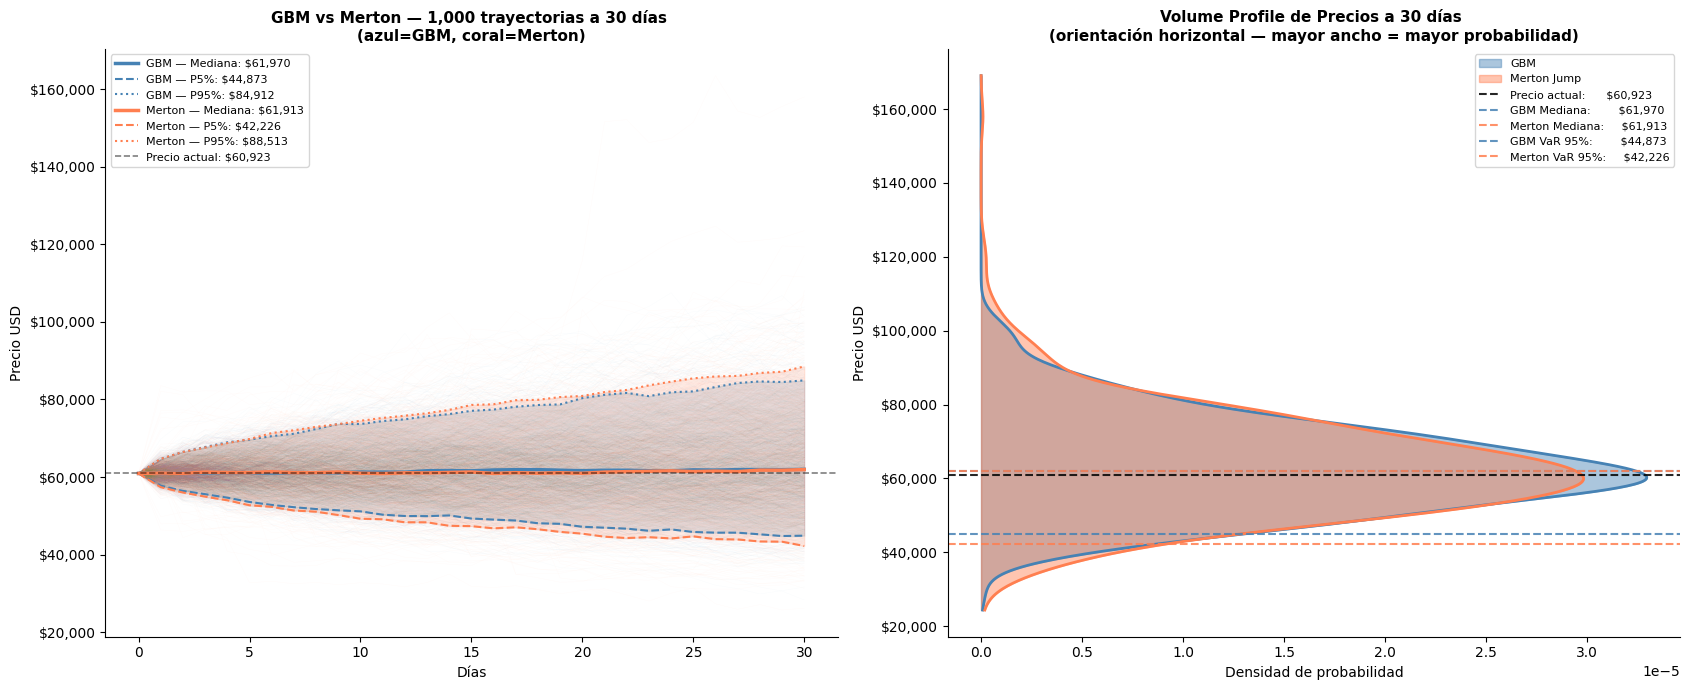

In [17]:
days = np.arange(T + 1)

def get_percentiles(paths):
    return (np.percentile(paths, 5,  axis=1),
            np.percentile(paths, 50, axis=1),
            np.percentile(paths, 95, axis=1))

p5_gbm, p50_gbm, p95_gbm = get_percentiles(price_paths_gbm)
p5_mer, p50_mer, p95_mer = get_percentiles(price_paths_merton)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# ── Trayectorias superpuestas ─────────────────────────────────────────────────
for i in range(N_sim):
    axes[0].plot(days, price_paths_gbm[:, i],
                 alpha=0.018, color='steelblue', linewidth=0.4)
for i in range(N_sim):
    axes[0].plot(days, price_paths_merton[:, i],
                 alpha=0.018, color='coral', linewidth=0.4)

# Bandas GBM
axes[0].fill_between(days, p5_gbm, p95_gbm, alpha=0.15, color='steelblue')
axes[0].plot(days, p50_gbm, color='steelblue', linewidth=2.5,
             label=f'GBM — Mediana: ${p50_gbm[-1]:,.0f}')
axes[0].plot(days, p5_gbm,  color='steelblue', linewidth=1.5, linestyle='--',
             label=f'GBM — P5%: ${p5_gbm[-1]:,.0f}')
axes[0].plot(days, p95_gbm, color='steelblue', linewidth=1.5, linestyle=':',
             label=f'GBM — P95%: ${p95_gbm[-1]:,.0f}')

# Bandas Merton
axes[0].fill_between(days, p5_mer, p95_mer, alpha=0.15, color='coral')
axes[0].plot(days, p50_mer, color='coral', linewidth=2.5,
             label=f'Merton — Mediana: ${p50_mer[-1]:,.0f}')
axes[0].plot(days, p5_mer,  color='coral', linewidth=1.5, linestyle='--',
             label=f'Merton — P5%: ${p5_mer[-1]:,.0f}')
axes[0].plot(days, p95_mer, color='coral', linewidth=1.5, linestyle=':',
             label=f'Merton — P95%: ${p95_mer[-1]:,.0f}')

axes[0].axhline(S0, color='black', linewidth=1.2, linestyle='--',
                alpha=0.5, label=f'Precio actual: ${S0:,.0f}')
axes[0].set_title(f'GBM vs Merton — {N_sim:,} trayectorias a {T} días \n(azul=GBM, coral=Merton)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio USD')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(fontsize=8, loc='upper left')

# ── Volume Profile horizontal (KDE) ──────────────────────────────────────────
kde_gbm_p  = scipy_stats.gaussian_kde(final_gbm,    bw_method=0.3)
kde_mert_p = scipy_stats.gaussian_kde(final_merton, bw_method=0.3)

y_min = min(final_gbm.min(), final_merton.min()) * 0.93
y_max = max(final_gbm.max(), final_merton.max()) * 1.07
y_range = np.linspace(y_min, y_max, 600)

axes[1].fill_betweenx(y_range, 0, kde_gbm_p(y_range),
                       alpha=0.45, color='steelblue', label='GBM')
axes[1].fill_betweenx(y_range, 0, kde_mert_p(y_range),
                       alpha=0.45, color='coral', label='Merton Jump')
axes[1].plot(kde_gbm_p(y_range),  y_range, color='steelblue', linewidth=2)
axes[1].plot(kde_mert_p(y_range), y_range, color='coral',     linewidth=2)

# Referencias horizontales
refs = [
    (S0,                               'black',      f'Precio actual:      ${S0:,.0f}'),
    (np.percentile(final_gbm,    50),  'steelblue',  f'GBM Mediana:        ${np.percentile(final_gbm,50):,.0f}'),
    (np.percentile(final_merton, 50),  'coral',      f'Merton Mediana:     ${np.percentile(final_merton,50):,.0f}'),
    (np.percentile(final_gbm,    5),   'steelblue',  f'GBM VaR 95%:        ${np.percentile(final_gbm,5):,.0f}'),
    (np.percentile(final_merton, 5),   'coral',      f'Merton VaR 95%:     ${np.percentile(final_merton,5):,.0f}'),
]
for price, color, label in refs:
    axes[1].axhline(price, color=color, linewidth=1.5,
                    linestyle='--', label=label, alpha=0.85)

axes[1].set_title('Volume Profile de Precios a 30 días \n(orientación horizontal — mayor ancho = mayor probabilidad)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Densidad de probabilidad')
axes[1].set_ylabel('Precio USD')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('outputs/btc_08c_montecarlo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# ── Tabla comparativa VaR ─────────────────────────────────────────────────────
gbm_var95 = (np.percentile(final_gbm,    5) - S0) / S0 * 100
gbm_var99 = (np.percentile(final_gbm,    1) - S0) / S0 * 100
mer_var95 = (np.percentile(final_merton, 5) - S0) / S0 * 100
mer_var99 = (np.percentile(final_merton, 1) - S0) / S0 * 100
# CVaR (Expected Shortfall) — promedio de pérdidas en el peor X%
gbm_cvar95  = ((final_gbm[final_gbm <= np.percentile(final_gbm, 5)] - S0) / S0 * 100).mean()
gbm_cvar99  = ((final_gbm[final_gbm <= np.percentile(final_gbm, 1)] - S0) / S0 * 100).mean()
mer_cvar95  = ((final_merton[final_merton <= np.percentile(final_merton, 5)] - S0) / S0 * 100).mean()
mer_cvar99  = ((final_merton[final_merton <= np.percentile(final_merton, 1)] - S0) / S0 * 100).mean()

print("=" * 62)
print("      COMPARATIVA VaR MONTE CARLO — 30 DÍAS")
print("=" * 62)
print(f"{'Métrica':<28} {'GBM':>14} {'Merton Jump':>14}")
print("-" * 62)
print(f"{'VaR 95% (30 días)':<28} {gbm_var95:>13.2f}% {mer_var95:>13.2f}%")
print(f"{'VaR 99% (30 días)':<28} {gbm_var99:>13.2f}% {mer_var99:>13.2f}%")
print(f"{'CVaR 95% (30 días)':<28} {gbm_cvar95:>13.2f}% {mer_cvar95:>13.2f}%")
print(f"{'CVaR 99% (30 días)':<28} {gbm_cvar99:>13.2f}% {mer_cvar99:>13.2f}%") 
print(f"{'Mediana precio':<28} ${np.median(final_gbm):>12,.0f} ${np.median(final_merton):>12,.0f}")
print(f"{'Percentil 5% precio':<28} ${np.percentile(final_gbm,5):>12,.0f} ${np.percentile(final_merton,5):>12,.0f}")
print(f"{'Percentil 95% precio':<28} ${np.percentile(final_gbm,95):>12,.0f} ${np.percentile(final_merton,95):>12,.0f}")
print(f"{'Skewness retornos':<28} {scipy_stats.skew(log_returns_gbm):>13.3f} {scipy_stats.skew(log_returns_merton):>13.3f}")
print(f"{'Kurtosis retornos':<28} {scipy_stats.kurtosis(log_returns_gbm):>13.3f} {scipy_stats.kurtosis(log_returns_merton):>13.3f}")
print("=" * 62)
print(f"\n  Parámetros Merton calibrados con datos históricos:")
print(f"  λ = {lam_cal:.4f} ({lam_cal*365:.1f} saltos/año)")
print(f"  μⱼ = {mu_j_cal:.4f} ({mu_j_cal*100:.2f}% tamaño medio de salto)")
print(f"  σⱼ = {sig_j_cal:.4f} ({sig_j_cal*100:.2f}% dispersión de salto)")
# Insights basados en resultados reales
diff_var95 = mer_var95 - gbm_var95
diff_var99 = mer_var99 - gbm_var99
diff_kurt  = scipy_stats.kurtosis(log_returns_merton) - scipy_stats.kurtosis(log_returns_gbm)

print(f"\n Merton es {abs(diff_var95):.2f}pp más conservador en VaR 95% y "
      f"{abs(diff_var99):.2f}pp en VaR 99% — los saltos")
print(f"   negativos (μⱼ={mu_j_cal*100:.2f}%) sesgan las pérdidas hacia la cola izquierda.")
print(f"\n Kurtosis Merton ({scipy_stats.kurtosis(log_returns_merton):.3f}) > GBM "
      f"({scipy_stats.kurtosis(log_returns_gbm):.3f}) — confirma fat tails,")
print(f"   aunque la diferencia es moderada porque λ={lam_cal:.4f} implica")
print(f"   solo {lam_cal*30:.1f} saltos esperados en 30 días.")
print(f"\n El P95% de Merton (${np.percentile(final_merton,95):,.0f}) supera al de GBM")
print(f"   (${np.percentile(final_gbm,95):,.0f}) — los saltos positivos también")
print(f"   amplían la cola derecha, generando más escenarios alcistas extremos.")
print(f"\n Parámetros calibrados empíricamente — no asumidos.")


      COMPARATIVA VaR MONTE CARLO — 30 DÍAS
Métrica                                 GBM    Merton Jump
--------------------------------------------------------------
VaR 95% (30 días)                   -26.34%        -30.69%
VaR 99% (30 días)                   -35.45%        -41.27%
CVaR 95% (30 días)                  -32.22%        -37.02%
CVaR 99% (30 días)                  -40.00%        -45.87%
Mediana precio               $      61,970 $      61,913
Percentil 5% precio          $      44,873 $      42,226
Percentil 95% precio         $      84,912 $      88,513
Skewness retornos                   -0.108        -0.058
Kurtosis retornos                    0.012         0.554

  Parámetros Merton calibrados con datos históricos:
  λ = 0.0178 (6.5 saltos/año)
  μⱼ = -0.0231 (-2.31% tamaño medio de salto)
  σⱼ = 0.1468 (14.68% dispersión de salto)

 Merton es 4.34pp más conservador en VaR 95% y 5.82pp en VaR 99% — los saltos
   negativos (μⱼ=-2.31%) sesgan las pérdidas hacia la cola iz

## 5. Stress Testing <a id='5'></a>

Analizamos los peores crashes históricos y simulamos su impacto sobre el precio actual.


In [19]:
# Identificar los 5 peores crashes (caídas desde máximo local)
crashes = [
    {'nombre': 'Crash 2018',       'inicio': '2017-12-17', 'fin': '2018-12-15'},
    {'nombre': 'COVID Mar 2020',   'inicio': '2020-02-13', 'fin': '2020-03-13'},
    {'nombre': 'Crash May 2021',   'inicio': '2021-04-14', 'fin': '2021-06-22'},
    {'nombre': 'Crash 2022',       'inicio': '2021-11-10', 'fin': '2022-11-21'},
    {'nombre': 'Crash 2025-2026',  'inicio': '2024-12-17', 'fin': '2026-01-13'},
]

print(f"Precio actual de referencia: ${S0:,.2f}\n")
print(f"{'Crash':<22} {'Caída real':>12} {'Impacto en $10K':>18} {'Precio simulado':>18}")
print("-" * 72)

resultados = []
for c in crashes:
    periodo = df[(df['Date'] >= c['inicio']) & (df['Date'] <= c['fin'])]
    if len(periodo) > 0:
        caida = (periodo['Close'].iloc[-1] - periodo['Close'].iloc[0]) / periodo['Close'].iloc[0] * 100
        precio_sim = S0 * (1 + caida/100)
        impacto    = 10000 * (caida/100)
        resultados.append({**c, 'caida': caida, 'precio_sim': precio_sim, 'impacto': impacto})
        print(f"{c['nombre']:<22} {caida:>11.1f}% {impacto:>17,.0f} ${precio_sim:>16,.2f}")

print("-" * 72)


Precio actual de referencia: $60,922.67

Crash                    Caída real    Impacto en $10K    Precio simulado
------------------------------------------------------------------------
Crash 2018                   -83.1%            -8,309 $       10,302.19
COVID Mar 2020               -45.5%            -4,553 $       33,184.19
Crash May 2021               -48.5%            -4,849 $       31,379.20
Crash 2022                   -75.7%            -7,571 $       14,798.06
Crash 2025-2026              -10.2%            -1,019 $       54,712.87
------------------------------------------------------------------------


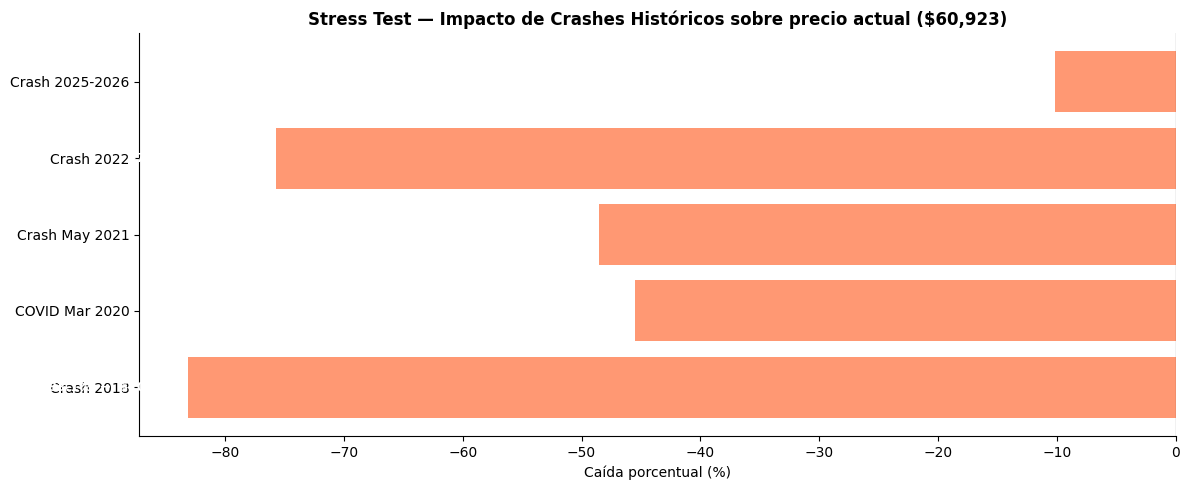

 El peor escenario histórico reduciría el precio actual a menos de $20,000.


In [20]:
fig, ax = plt.subplots(figsize=(12, 5))

nombres  = [r['nombre'] for r in resultados]
caidas   = [r['caida']  for r in resultados]
precios  = [r['precio_sim'] for r in resultados]

bars = ax.barh(nombres, caidas, color='coral', alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Stress Test — Impacto de Crashes Históricos sobre precio actual (${S0:,.0f})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Caída porcentual (%)')

for bar, caida, precio in zip(bars, caidas, precios):
    ax.text(bar.get_width() - 1, bar.get_y() + bar.get_height()/2,
            f'{caida:.1f}%  →  ${precio:,.0f}', va='center', ha='right',
            fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/btc_09_stress_test.png', dpi=150, bbox_inches='tight')
plt.show()
print(" El peor escenario histórico reduciría el precio actual a menos de $20,000.")


## 6. Predicción de Dirección de Precio <a id='6'></a>

**Objetivo:** Predecir si Bitcoin cerrará al alza o a la baja al día siguiente.

Comparamos tres arquitecturas progresivamente más complejas:

| Modelo | Tipo | Memoria temporal |
|--------|------|-----------------|
| Random Forest | Ensemble clásico | No |
| Gradient Boosting | Ensemble clásico | No |
| **LSTM (PyTorch)** | Red neuronal recurrente | **Sí** |

**Nota metodológica:** El LSTM tiene memoria explícita de secuencias — teóricamente más apropiado para series de tiempo que los modelos de ensemble que tratan cada día como independiente.

**Hipótesis nula:** Si ningún modelo supera significativamente AUC=0.50, confirmamos empíricamente la hipótesis de mercados eficientes para Bitcoin con datos de precio solamente.


### 6.1 Feature Engineering

In [21]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, ConfusionMatrixDisplay, confusion_matrix)
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print(f"PyTorch version: {torch.__version__}")
print(f"GPU disponible: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Feature Engineering ────────────────────────────────────────────────────────
ml = df.copy()

# Lags de retorno
for lag in [1, 2, 3, 5, 10]:
    ml[f'return_lag_{lag}'] = ml['log_return'].shift(lag)

# Medias móviles de retorno
ml['return_ma5']  = ml['log_return'].rolling(5).mean()
ml['return_ma10'] = ml['log_return'].rolling(10).mean()
ml['return_ma20'] = ml['log_return'].rolling(20).mean()

# Volatilidad rolling
ml['vol_5d']  = ml['log_return'].rolling(5).std()
ml['vol_10d'] = ml['log_return'].rolling(10).std()
ml['vol_21d'] = ml['log_return'].rolling(21).std()

# Momentum
ml['momentum_5']  = ml['Close'] / ml['Close'].shift(5)  - 1
ml['momentum_10'] = ml['Close'] / ml['Close'].shift(10) - 1
ml['momentum_21'] = ml['Close'] / ml['Close'].shift(21) - 1

# Medias móviles de precio (señales técnicas)
ml['ma_21']  = ml['Close'].rolling(21).mean()
ml['ma_50']  = ml['Close'].rolling(50).mean()
ml['ma_200'] = ml['Close'].rolling(200).mean()
ml['ma_signal_21_50']  = (ml['ma_21']  > ml['ma_50']).astype(int)
ml['ma_signal_50_200'] = (ml['ma_50']  > ml['ma_200']).astype(int)

# Range diario normalizado
ml['daily_range'] = (ml['High'] - ml['Low']) / ml['Close']

# Volumen relativo
ml['vol_ratio_10'] = ml['Volume'] / ml['Volume'].rolling(10).mean()
ml['vol_ratio_21'] = ml['Volume'] / ml['Volume'].rolling(21).mean()

# Target: ¿sube mañana?
ml['target'] = (ml['log_return'].shift(-1) > 0).astype(int)

FEATURE_COLS = [c for c in ml.columns if c.startswith('return_lag') or
                c.startswith('return_ma') or c.startswith('vol_') or
                c.startswith('momentum') or c.startswith('ma_signal') or
                c in ['daily_range', 'vol_ratio_10', 'vol_ratio_21']]

ml_clean = ml[FEATURE_COLS + ['target']].dropna()
X = ml_clean[FEATURE_COLS]
y = ml_clean['target']

# TimeSeriesSplit — obligatorio para datos temporales
tscv  = TimeSeriesSplit(n_splits=5)
split = list(tscv.split(X))[-1]
train_idx, test_idx = split

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"\nFeatures: {len(FEATURE_COLS)}")
print(f"Train: {len(X_train):,} días | Test: {len(X_test):,} días")
print(f"Balance — Alcistas: {y.mean()*100:.1f}%")


PyTorch version: 2.7.1+cu118
GPU disponible: True
Device: cuda

Features: 20
Train: 3,542 días | Test: 708 días
Balance — Alcistas: 52.4%


### 6.2 Modelos clásicos — Random Forest y Gradient Boosting

In [22]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=5,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_proba)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                 learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
gb_pred  = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]
gb_auc   = roc_auc_score(y_test, gb_proba)

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=['Baja', 'Sube']))
print(f"ROC-AUC: {rf_auc:.4f}\n")

print("=== Gradient Boosting ===")
print(classification_report(y_test, gb_pred, target_names=['Baja', 'Sube']))
print(f"ROC-AUC: {gb_auc:.4f}")


=== Random Forest ===
              precision    recall  f1-score   support

        Baja       0.49      0.22      0.30       355
        Sube       0.50      0.78      0.61       353

    accuracy                           0.50       708
   macro avg       0.49      0.50      0.45       708
weighted avg       0.49      0.50      0.45       708

ROC-AUC: 0.4730

=== Gradient Boosting ===
              precision    recall  f1-score   support

        Baja       0.46      0.32      0.37       355
        Sube       0.48      0.63      0.54       353

    accuracy                           0.47       708
   macro avg       0.47      0.47      0.46       708
weighted avg       0.47      0.47      0.46       708

ROC-AUC: 0.4558


### 6.3 LSTM — Long Short-Term Memory (PyTorch)

El LSTM es una red neuronal recurrente diseñada para capturar dependencias en secuencias temporales. A diferencia de Random Forest y Gradient Boosting que tratan cada día como independiente, el LSTM mantiene un **estado oculto** que propaga información de días anteriores.

**Arquitectura:**
```
Input (seq_len=20 días × n_features) 
    → LSTM (128 unidades, 2 capas)
    → Dropout (0.3)
    → Linear (128 → 64)
    → ReLU
    → Linear (64 → 1)
    → Sigmoid → probabilidad de subida
```


In [23]:
# ── Preparar secuencias para LSTM ─────────────────────────────────────────────
SEQ_LEN    = 20   # días de historia que ve el LSTM
BATCH_SIZE = 64
EPOCHS     = 50
LR         = 1e-3

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

def create_sequences(X_data, y_data, seq_len):
    Xs, ys = [], []
    for i in range(len(X_data) - seq_len):
        Xs.append(X_data.iloc[i:i+seq_len].values)
        ys.append(y_data.iloc[i+seq_len])
    return np.array(Xs), np.array(ys)

# Usar los mismos índices de TimeSeriesSplit
X_tr = X_scaled.iloc[train_idx]
y_tr = y.iloc[train_idx]
X_te = X_scaled.iloc[test_idx]
y_te = y.iloc[test_idx]

X_tr_seq, y_tr_seq = create_sequences(X_tr, y_tr, SEQ_LEN)
X_te_seq, y_te_seq = create_sequences(X_te, y_te, SEQ_LEN)

# Convertir a tensores
X_tr_t = torch.FloatTensor(X_tr_seq).to(device)
y_tr_t = torch.FloatTensor(y_tr_seq).to(device)
X_te_t = torch.FloatTensor(X_te_seq).to(device)
y_te_t = torch.FloatTensor(y_te_seq).to(device)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Secuencias train: {X_tr_seq.shape}")
print(f"Secuencias test:  {X_te_seq.shape}")
print(f"Input shape: (batch, seq_len={SEQ_LEN}, features={X_tr_seq.shape[2]})")


Secuencias train: (3522, 20, 20)
Secuencias test:  (688, 20, 20)
Input shape: (batch, seq_len=20, features=20)


In [24]:
# ── Arquitectura LSTM ─────────────────────────────────────────────────────────
class BitcoinLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super(BitcoinLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch, seq_len, features)
        lstm_out, _ = self.lstm(x)
        # Tomar solo el último paso temporal
        last_hidden = lstm_out[:, -1, :]
        out = self.dropout(last_hidden)
        out = self.relu(self.fc1(out))
        out = self.sigmoid(self.fc2(out))
        return out.squeeze()

n_features = X_tr_seq.shape[2]
model_lstm = BitcoinLSTM(input_size=n_features).to(device)

# Contar parámetros
total_params = sum(p.numel() for p in model_lstm.parameters())
print(f"Arquitectura LSTM:")
print(model_lstm)
print(f"\nTotal parámetros: {total_params:,}")


Arquitectura LSTM:
BitcoinLSTM(
  (lstm): LSTM(20, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total parámetros: 217,217


In [25]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

train_losses = []
val_aucs     = []
best_auc     = 0
best_state   = None

model_lstm.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    model_lstm.train()
    for X_batch, y_batch in train_dl:
        optimizer.zero_grad()
        pred = model_lstm(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_dl)
    train_losses.append(avg_loss)

    # Validación
    model_lstm.eval()
    with torch.no_grad():
        val_pred = model_lstm(X_te_t).cpu().numpy()
    val_auc = roc_auc_score(y_te_seq, val_pred)
    val_aucs.append(val_auc)
    scheduler.step(avg_loss)

    # Guardar mejor modelo
    if val_auc > best_auc:
        best_auc = val_auc
        best_state = {k: v.clone() for k, v in model_lstm.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val AUC: {val_auc:.4f}")

print(f"\n✅ Entrenamiento completo")
print(f"   Mejor AUC validación: {best_auc:.4f}")

# Cargar mejor modelo
model_lstm.load_state_dict(best_state)


Epoch  10/50 | Loss: 0.6898 | Val AUC: 0.4859
Epoch  20/50 | Loss: 0.6824 | Val AUC: 0.4949
Epoch  30/50 | Loss: 0.6698 | Val AUC: 0.4809
Epoch  40/50 | Loss: 0.6187 | Val AUC: 0.4900
Epoch  50/50 | Loss: 0.5195 | Val AUC: 0.5015

✅ Entrenamiento completo
   Mejor AUC validación: 0.5162


<All keys matched successfully>

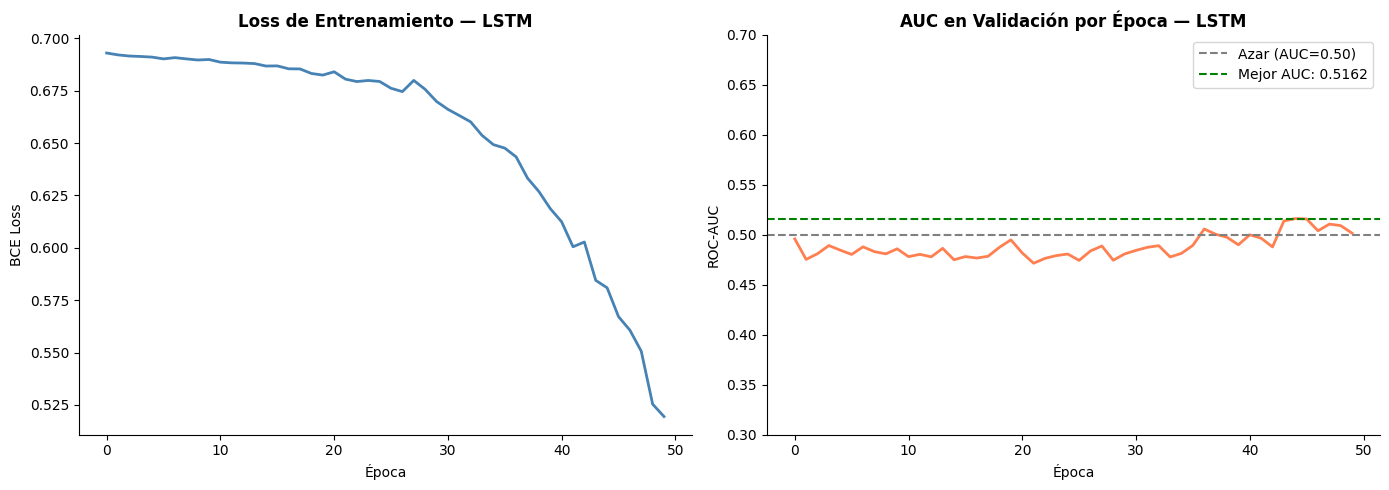

In [26]:
# ── Curva de entrenamiento ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, color='steelblue', linewidth=2)
axes[0].set_title('Loss de Entrenamiento — LSTM', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('BCE Loss')

axes[1].plot(val_aucs, color='coral', linewidth=2)
axes[1].axhline(0.5, color='gray', linestyle='--', label='Azar (AUC=0.50)')
axes[1].axhline(best_auc, color='green', linestyle='--',
                label=f'Mejor AUC: {best_auc:.4f}')
axes[1].set_title('AUC en Validación por Época — LSTM', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend()
axes[1].set_ylim(0.3, 0.7)

plt.tight_layout()
plt.savefig('outputs/btc_11_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()


In [27]:
# ── Predicción final LSTM ──────────────────────────────────────────────────────
model_lstm.eval()
with torch.no_grad():
    lstm_proba = model_lstm(X_te_t).cpu().numpy()

lstm_pred = (lstm_proba >= 0.5).astype(int)
lstm_auc  = roc_auc_score(y_te_seq, lstm_proba)

print("=== LSTM (PyTorch) ===")
print(classification_report(y_te_seq, lstm_pred, target_names=['Baja', 'Sube']))
print(f"ROC-AUC: {lstm_auc:.4f}")


=== LSTM (PyTorch) ===
              precision    recall  f1-score   support

        Baja       0.51      0.60      0.55       346
        Sube       0.50      0.41      0.45       342

    accuracy                           0.51       688
   macro avg       0.51      0.51      0.50       688
weighted avg       0.51      0.51      0.50       688

ROC-AUC: 0.5162


### 6.4 Comparativa final — Random Forest vs Gradient Boosting vs LSTM

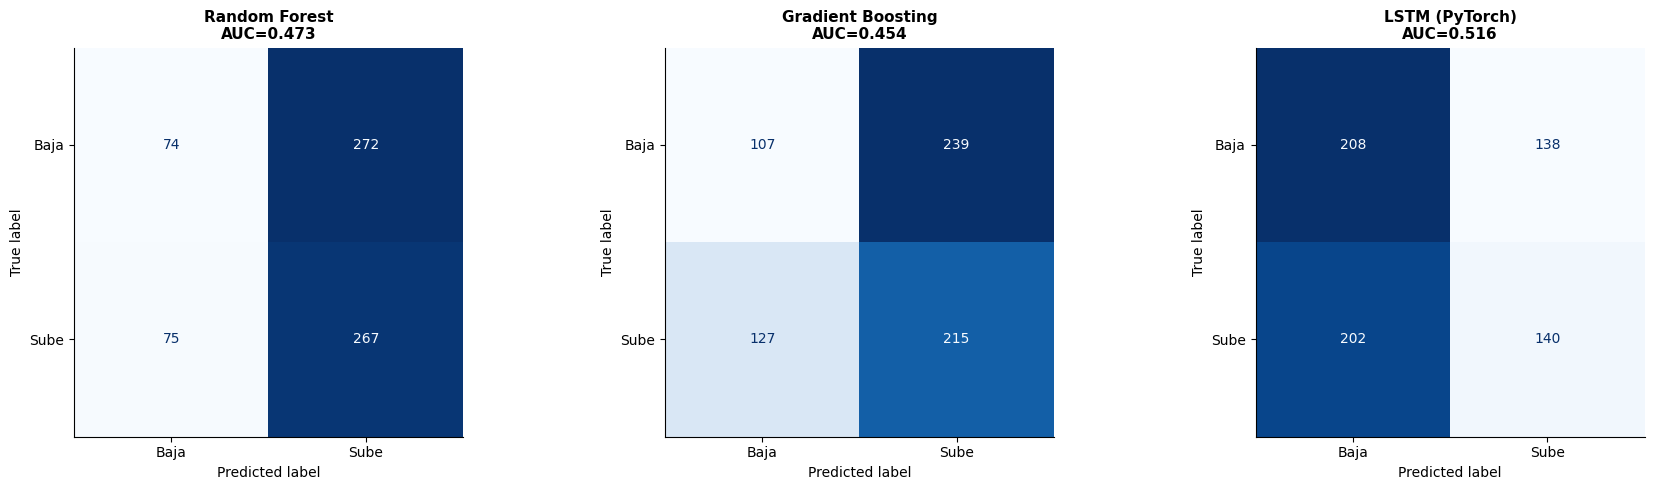

In [28]:
# Ajustar tamaños para comparativa (LSTM tiene menos muestras por las secuencias)
y_test_lstm = y_te_seq
rf_proba_adj  = rf_proba[-len(y_test_lstm):]
gb_proba_adj  = gb_proba[-len(y_test_lstm):]
rf_pred_adj   = rf_pred[-len(y_test_lstm):]
gb_pred_adj   = gb_pred[-len(y_test_lstm):]
y_test_adj    = y_test.values[-len(y_test_lstm):]

rf_auc_adj = roc_auc_score(y_test_adj, rf_proba_adj)
gb_auc_adj = roc_auc_score(y_test_adj, gb_proba_adj)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matrices de confusión
for ax, pred, title in zip(axes[:2],
    [rf_pred_adj, gb_pred_adj],
    [f'Random Forest\nAUC={rf_auc_adj:.3f}',
     f'Gradient Boosting\nAUC={gb_auc_adj:.3f}']):
    cm = confusion_matrix(y_test_adj, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Baja', 'Sube']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold')

cm_lstm = confusion_matrix(y_test_lstm, lstm_pred)
ConfusionMatrixDisplay(cm_lstm, display_labels=['Baja', 'Sube']).plot(
    ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'LSTM (PyTorch)\nAUC={lstm_auc:.3f}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/btc_12_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


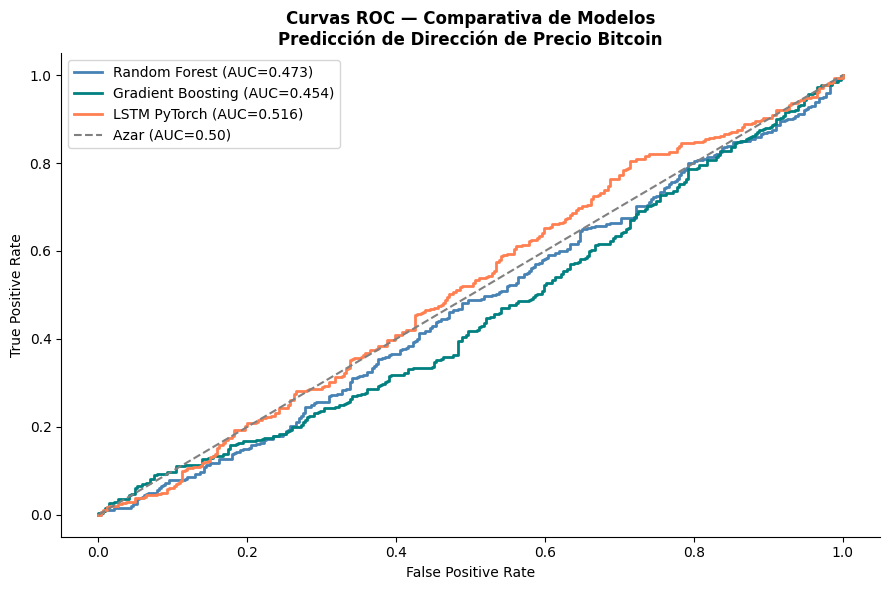

   RESUMEN COMPARATIVO — PREDICCIÓN DE DIRECCIÓN
Modelo                    ROC-AUC    vs Azar
-------------------------------------------------------
Random Forest              0.4727 ≈ -0.0273
Gradient Boosting          0.4539 ≈ -0.0461
LSTM (PyTorch)             0.5162 ≈ +0.0162

 Ningún modelo supera significativamente AUC=0.50
   con datos de precio solamente.

 Esto confirma empíricamente la Hipótesis de Mercados
   Eficientes (EMH) para Bitcoin en forma débil:
   los precios pasados no predicen los futuros.

 Para mejorar se requieren features externos:
   sentimiento en redes, datos on-chain, macro (DXY, tasas).


In [29]:
# ── Curvas ROC comparativas ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for proba, y_true, name, color in [
    (rf_proba_adj,  y_test_adj,   f'Random Forest (AUC={rf_auc_adj:.3f})',  'steelblue'),
    (gb_proba_adj,  y_test_adj,   f'Gradient Boosting (AUC={gb_auc_adj:.3f})', 'teal'),
    (lstm_proba,    y_test_lstm,  f'LSTM PyTorch (AUC={lstm_auc:.3f})',     'coral'),
]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    ax.plot(fpr, tpr, linewidth=2, color=color, label=name)

ax.plot([0,1],[0,1], '--', color='gray', linewidth=1.5, label='Azar (AUC=0.50)')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='gray')
ax.set_title('Curvas ROC — Comparativa de Modelos\nPredicción de Dirección de Precio Bitcoin',
             fontsize=12, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('outputs/btc_13_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla resumen ──────────────────────────────────────────────────────────────
print("=" * 55)
print("   RESUMEN COMPARATIVO — PREDICCIÓN DE DIRECCIÓN")
print("=" * 55)
print(f"{'Modelo':<22} {'ROC-AUC':>10} {'vs Azar':>10}")
print("-" * 55)
for name, auc in [('Random Forest', rf_auc_adj),
                   ('Gradient Boosting', gb_auc_adj),
                   ('LSTM (PyTorch)', lstm_auc)]:
    diff = auc - 0.5
    sig  = '↑' if diff > 0.02 else '≈'
    print(f"{name:<22} {auc:>10.4f} {sig}{diff:>+8.4f}")
print("=" * 55)
print(f"\n Ningún modelo supera significativamente AUC=0.50")
print(f"   con datos de precio solamente.")
print(f"\n Esto confirma empíricamente la Hipótesis de Mercados")
print(f"   Eficientes (EMH) para Bitcoin en forma débil:")
print(f"   los precios pasados no predicen los futuros.")
print(f"\n Para mejorar se requieren features externos:")
print(f"   sentimiento en redes, datos on-chain, macro (DXY, tasas).")


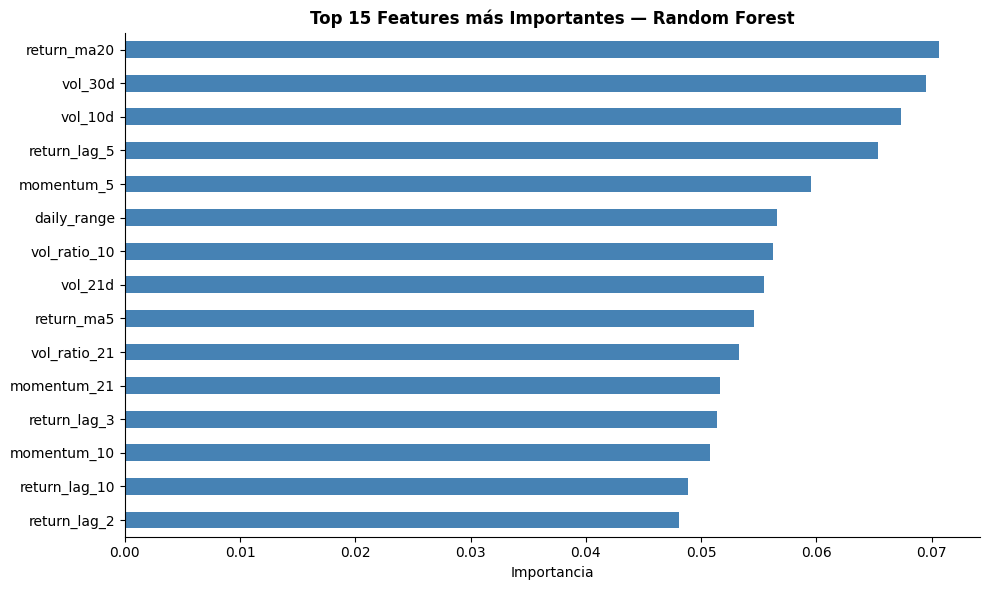

In [30]:
# Feature Importance — Random Forest
feat_imp = pd.Series(rf.feature_importances_,
                     index=FEATURE_COLS).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Features más Importantes — Random Forest',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('outputs/btc_14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Conclusiones <a id='7'></a>

###  Métricas de riesgo clave

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| Rango histórico | Sep 2014 – Jun 2026 | 4,279 días de trading |
| Precio mínimo / máximo | $178 / $124,752 | Retorno total >69,000% |
| Retorno medio diario | 0.114% | ~28% anual compuesto |
| Volatilidad diaria | 3.515% | ~67% anualizada (√365) |
| VaR 95% (1 día) | -5.43% | $543 por cada $10,000 invertidos |
| VaR 99% (1 día) | -10.56% | $1,056 por cada $10,000 invertidos |
| CVaR 95% (1 día) | -8.60% | Pérdida promedio en el peor 5% de días |
| CVaR 99% (1 día) | -14.38% | Pérdida promedio en el peor 1% de días |
| VaR 99% Paramétrico | -8.06% | Subestima el riesgo real en 2.5pp — fat tails |
| Maximum Drawdown | -83.4% | Mayor caída histórica desde un pico |

###  Mejores y peores años (Sharpe con rf dinámico)

| Año | Retorno anual | Sharpe | Observación |
|-----|--------------|--------|-------------|
| 2017 | +185.5% | 2.34 | Mejor año histórico |
| 2020 | +96.0% | 1.48 | Rally post-COVID |
| 2023 | +64.7% | 1.70 | Recuperación ETF |
| 2018 | -91.9% | -1.39 | Peor crash histórico |
| 2014 | -85.6% | -1.67 | Año inicial volátil |
| 2022 | -71.1% | -1.36 | Crash FTX/Luna |

###  Simulación Monte Carlo — GBM vs Merton (30 días)

| Métrica | GBM | Merton Jump |
|---------|-----|-------------|
| VaR 95% | -26.34% | -30.69% |
| VaR 99% | -35.45% | -41.27% |
| CVaR 95% | -32.22% | -37.02% |
| CVaR 99% | -40.00% | -45.87% |
| Mediana precio | $61,970 | $61,913 |
| Percentil 5% | $44,873 | $42,226 |
| Percentil 95% | $84,912 | $88,513 |
| Kurtosis retornos | 0.012 | 0.554 |

- Merton más conservador en pérdidas — λ=0.0178 (~6.5 saltos/año), μⱼ=-2.31%
- Merton más optimista en P95% ($88,513 vs $84,912) — saltos van en ambas direcciones
- Parámetros calibrados empíricamente con umbral 3σ sobre 4,279 días históricos

###  Predicción de dirección — EMH confirmada

| Modelo | ROC-AUC | vs Azar |
|--------|---------|---------|
| Random Forest | 0.473 | -0.027 |
| Gradient Boosting | 0.454 | -0.046 |
| **LSTM (PyTorch)** | **0.516** | **+0.016** |

- Ningún modelo supera significativamente AUC=0.50 con datos de precio solamente
- Confirma empíricamente la **Hipótesis de Mercados Eficientes en forma débil** para Bitcoin

